In [48]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [49]:
df = pd.read_csv("New_Cleaned_Titanic_Dataset.csv")

In [50]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop unnecessary columns
df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'],
        axis=1,
        inplace=True,
        errors='ignore')

# Feature Engineering
df['Family_Size'] = df['SibSp'] + df['Parch']

df['Is_Alone'] = np.where(df['Family_Size']==0,1,0)

# Encoding
df = pd.get_dummies(df, drop_first=True)

**FEATURE ENGINEERING**

In [51]:
#Counting family members
df['Family_size'] = df['SibSp'] + df['Parch']

In [52]:
#Passenger is alone or not
# 1 = traveling alone
# 0 = not alone
df['Is_alone'] = np.where(df['Family_size'] == 0, 1, 0)

In [53]:
# Age Group
df['Age_Group'] = pd.cut(df['Age'], bins=[0,12,19,35,60,100], labels=['Child','Teen','Young Adult','Adult','Senior'])

In [54]:
df = pd.get_dummies(df, drop_first=True)

In [55]:
X = df.drop('Survived', axis=1)  # FEATURES
y = df['Survived'] # TARGET

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [57]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**MODEL SELECTION**

Model 1 — Logistic Regression

In [58]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Model 2 — Decision Tree

In [59]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

Model 3 — Random Forest

In [60]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**COMPARING PERFORMANCE**

In [61]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7988826815642458
Decision Tree Accuracy: 0.8100558659217877
Random Forest Accuracy: 0.8268156424581006


In [62]:
# Classification Report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [63]:
print("LOGISTIC REGRESSION REPORT")
print(classification_report(y_test, lr_pred))

LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [64]:
print("DECISION TREE REPORT")
print(classification_report(y_test, dt_pred))

DECISION TREE REPORT
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       105
           1       0.76      0.78      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.81      0.81      0.81       179



In [65]:
print("RANDOM FOREST REPORT")
print(classification_report(y_test, rf_pred))

RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



**Confusion Matrix**

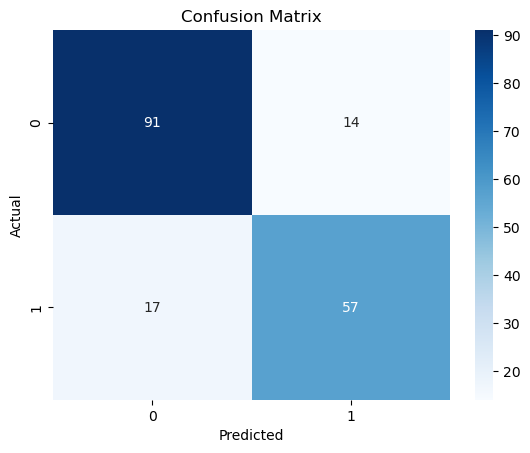

In [66]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

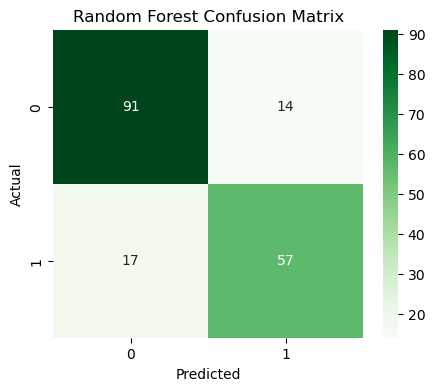

In [67]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**HYPERPARAMETER TUNING**

GridSearchCV

In [68]:
params = {
    'n_estimators': [50,100,200],
    'max_depth': [None,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [69]:
# Best parameter
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 200}


In [70]:
# Best Model Accuracy
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



**INTERPRETATION**

In [71]:
importance = best_model.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
print(feat_imp)

                  Feature  Importance
7                Sex_male    0.417756
4                    Fare    0.165038
0                  Pclass    0.119056
1                     Age    0.097822
10            Family_size    0.050099
5             Family_Size    0.046010
2                   SibSp    0.025706
9              Embarked_S    0.017492
3                   Parch    0.016791
11               Is_alone    0.008196
6                Is_Alone    0.007490
13  Age_Group_Young Adult    0.007396
14        Age_Group_Adult    0.007320
8              Embarked_Q    0.006247
12         Age_Group_Teen    0.004596
15       Age_Group_Senior    0.002987


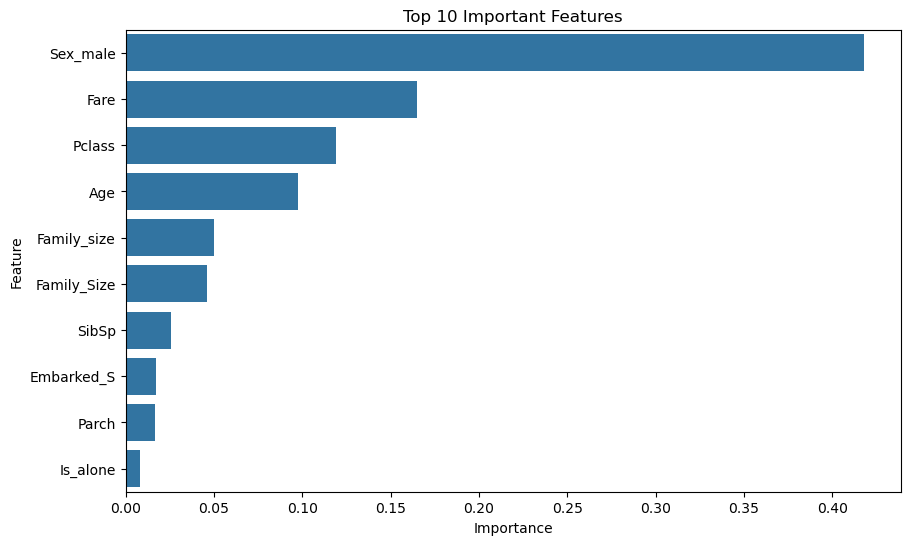

In [72]:
# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [73]:
# Model Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)]})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.798883
1        Decision Tree  0.810056
2        Random Forest  0.826816


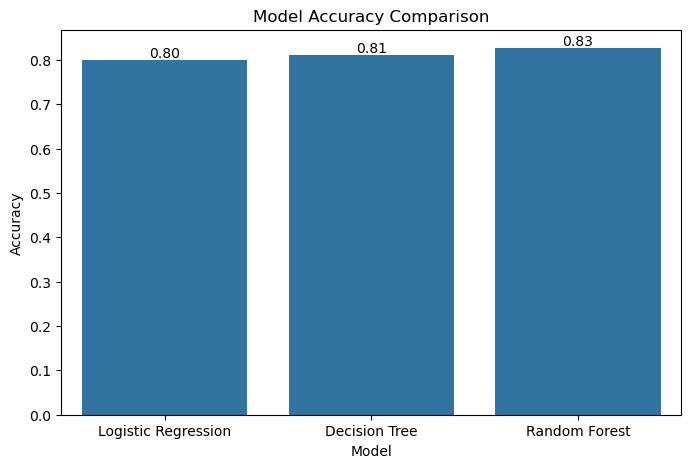

In [78]:
plt.figure(figsize=(8,5))
ax = sns.barplot(
    x='Model',
    y='Accuracy',
    data=results)
for i in ax.containers:ax.bar_label(i,fmt='%.2f')
plt.title("Model Accuracy Comparison")
plt.show()

In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.798883   0.771429  0.729730  0.750000
1        Decision Tree  0.810056   0.763158  0.783784  0.773333
2        Random Forest  0.826816   0.802817  0.770270  0.786207


**KEY INSIGHTS FROM MY VISUALIZATIONS**

**1.** The machine learning pipeline helped transform raw Titanic data into a structured format suitable for prediction and analysis.

**2.** Feature engineering improved the model performance by creating useful new features like Family_Size and Is_Alone.

**3.** The feature importance graph indicated that gender, fare amount, passenger class, and age were the most influential factors affecting survival.

**4.** The confusion matrix showed that the Random Forest model correctly classified most passengers with only a small number of incorrect predictions.

**5.** The comparison table revealed that Random Forest achieved the highest accuracy and F1-score among all trained models.

**6.** Accuracy and classification reports helped evaluate how effectively the models predicted passenger survival on unseen test data.

**7.** The project demonstrated how machine learning models can identify hidden patterns and relationships from real-world datasets.

**8.** Overall, the ML pipeline provided a complete understanding of data preprocessing, model training, evaluation, and interpretation, making it easier to build accurate predictive systems.

**CONCLUSION**

* Among all machine learning models, Random Forest achieved the best performance with highest accuracy and balanced classification metrics.

* Feature importance analysis showed that gender, passenger class, fare amount, and age were the most influential factors affecting passenger survival.

* The project successfully demonstrated the complete machine learning pipeline from preprocessing to interpretation using the Titanic dataset.